In [60]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [35]:
pd.options.display.max_columns = 120

np.random.seed(1147)

In [2]:
# Upload manually cleaning data
from google.colab import files
uploaded = files.upload()

Saving design_matrix_ver_1.csv to design_matrix_ver_1.csv


In [3]:
df = pd.read_csv("design_matrix_ver_1.csv")
df = df.set_index(['HEATID', 'DATETIME'])
df.head()

,,16A,25A,25A1,26A,3A,3A (shop pipe waste),3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,...,VALNI,VALAS,VALSN,VALN,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
HEATID,DATETIME,,,,,,,,,,,,,,,,,,,,,
5F0002,2015-01-01 01:31:00.000000000,0.0,0.0,0.0,0.0,105928.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1627.0,383.000000,3659.0,1160.0,1021.0,48.625
5F0003,2015-01-01 02:17:30.000000000,0.0,0.0,0.0,0.0,108033.0,0.0,0.0,0.0,0.0,0.0,...,0.1075,0.0053,0.0068,0.0361,1641.0,683.000000,3469.0,1117.0,957.0,48.625
5F0004,2015-01-01 03:17:30.000000000,0.0,0.0,0.0,0.0,128245.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1636.0,700.000000,3605.0,1204.0,789.0,47.375
5F0005,2015-01-01 04:06:00.000000000,0.0,0.0,0.0,0.0,106941.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1630.0,625.333333,3678.0,1191.0,812.0,49.250
5F0006,2015-01-01 04:54:24.000000000,0.0,0.0,0.0,0.0,127035.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1622.0,654.600000,3655.0,1171.0,882.0,49.875


In [ ]:
# Ignore this cell for now, we can return to look at importance of steel chemistry later.

# df_with_ls_analysis = df[~df['VALC'].isna()]    # Split the dataset into those with final steel chemical analysis, and those without. Later on we can test how important it is to have this feature.
# # df_with_ls_analysis = df_with_ls_analysis.dropna(axis='columns')
# df_with_ls_analysis = df_with_ls_analysis.dropna(axis='rows')
# df_with_ls_analysis.describe()

In [ ]:
# df_with_ls_analysis_train, df_with_ls_analysis_test = train_test_split(df_with_ls_analysis, train_size=0.7)

In [4]:
# Remove features with perfectly 0 variance
df = df.drop(columns=df.columns[df.var(axis='rows') == 0])

# Split the dataset into those with or without steel chemistry.
# For now, remove the steel chemistry feature as it is mostly (~85%) empty.
df = df[df['VALC'].isna()]

# Drop columns that are all NaN
df = df.dropna(axis='columns', how='all')

# Drop rows that contain any NaN
df = df.dropna(axis='rows')

# Define feature and target columns
FEATURES = list(df.columns[:-1])
TARGET = 'MW'

df.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,...,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000,16911.000000
mean,5046.419135,136.103542,2292.335285,11.216368,113957.310271,1066.367157,2.877654,0.011531,7.033292,147.269824,...,3.791319,0.590148,2659.102359,2.068299,1635.502847,982.395617,4292.221335,762.949441,901.256519,48.570531
std,4942.693717,904.675505,4836.046339,316.184722,25724.755668,5536.199276,154.345988,1.088153,76.715107,2408.968325,...,185.910261,76.744259,8917.298415,0.350561,16.725183,698.369872,501.586274,150.643999,311.330350,8.787742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.000000,0.000000,0.000000,0.000000,-999.999000
25%,0.000000,0.000000,0.000000,0.000000,109894.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.500000,726.125000,3958.000000,664.000000,696.000000,47.250000
50%,5060.000000,0.000000,0.000000,0.000000,121168.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1635.000000,862.000000,4274.000000,752.000000,886.000000,48.750000
75%,9253.500000,0.000000,0.000000,0.000000,127959.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1646.000000,996.000000,4598.000000,838.000000,1084.000000,50.375000
max,49366.000000,20854.000000,24776.000000,13890.000000,139916.000000,69506.000000,10052.000000,120.000000,1900.000000,76639.000000,...,24000.000000,9980.000000,86160.000000,8.000000,1737.000000,9999.000000,8886.000000,2209.000000,10884.000000,85.000000


<Axes: >

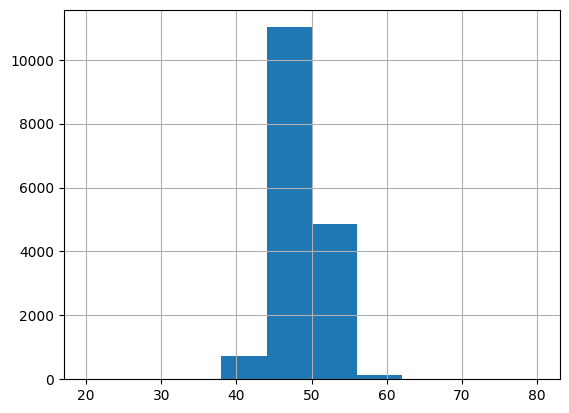

In [36]:
df['MW'].hist(range=(20,80))

In [37]:
# Qualitatively guess that any instances of "MW" being either less than 35 or more than 70 are likely false data or equipment failures.
# These energy consumption levels are thermodynamically impossible.

df = df[(df['MW']>35) & (df['MW']<70)]

In [6]:
# Train/test split
df_train, df_test = train_test_split(df, train_size=0.7)

df_train.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,...,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000,11740.000000
mean,5037.037308,145.219080,2239.557836,11.999148,114210.345656,1103.071039,3.528024,0.006388,7.180579,148.783731,...,4.484838,0.850085,2682.649063,2.072743,1635.518234,979.849596,4299.491908,763.993356,899.370187,48.784497
std,4921.177483,936.080605,4772.416030,327.501933,25546.168082,5604.063050,172.755826,0.692193,77.939692,2453.786700,...,222.683484,92.107818,9070.973366,0.335060,16.671109,698.593482,481.984022,148.517140,299.722267,2.812700
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1517.000000,1.000000,2632.000000,286.000000,0.000000,35.500000
25%,0.000000,0.000000,0.000000,0.000000,110167.750000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1020.000000,2.000000,1624.666667,725.000000,3960.750000,665.000000,695.000000,47.250000
50%,5060.000000,0.000000,0.000000,0.000000,121163.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1080.000000,2.000000,1635.000000,862.633333,4277.500000,753.000000,886.500000,48.750000
75%,9230.750000,0.000000,0.000000,0.000000,127979.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1260.000000,2.000000,1645.750000,995.931818,4602.250000,837.000000,1082.000000,50.375000
max,35270.000000,20854.000000,24776.000000,13890.000000,139916.000000,69506.000000,10052.000000,75.000000,1900.000000,76639.000000,...,24000.000000,9980.000000,86160.000000,8.000000,1737.000000,9999.000000,8886.000000,2209.000000,5322.000000,69.500000


In [7]:
df_test.describe()

,16A,25A,25A1,26A,3A,3ACh,3B23,Aluminum briquet,Artificial graphite 0.1-2.5 mm,B11,...,Secondary aluminum AV 87 Added,Steel scrap G/B 25A Added,total_charging_time,num_baskets,TEMP,VALO2_PPM,O2_AMOUNT,GAS_AMOUNT,INJ_AMOUNT_CARBON,MW
count,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.0,5032.000000,5032.000000,...,5032.000000,5032.0,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000
mean,5118.540938,115.798887,2411.727146,9.699921,114457.380167,967.949523,1.439785,0.0,6.883943,142.026828,...,2.248211,0.0,2519.248808,2.073331,1635.439472,986.379839,4308.932432,765.193760,909.043720,48.813742
std,4991.114744,827.434156,4963.906353,292.830737,25058.498986,5328.992756,102.133467,0.0,74.870776,2299.797724,...,21.432698,0.0,8178.151101,0.347619,16.678268,696.310753,473.583683,150.072521,330.791911,2.765367
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,1.000000,1555.000000,2.500000,2640.000000,360.000000,58.000000,35.250000
25%,0.000000,0.000000,0.000000,0.000000,110239.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,1020.000000,2.000000,1624.243056,729.787500,3981.000000,663.000000,701.000000,47.250000
50%,5090.000000,0.000000,0.000000,0.000000,121531.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,1080.000000,2.000000,1635.000000,861.291667,4278.000000,752.000000,888.500000,48.750000
75%,9340.250000,0.000000,0.000000,0.000000,127983.250000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,1260.000000,2.000000,1646.000000,994.678571,4598.250000,841.000000,1090.000000,50.500000
max,49366.000000,12053.000000,24510.000000,10550.000000,139867.000000,62311.000000,7245.000000,0.0,1870.000000,61870.000000,...,1000.000000,0.0,85560.000000,7.000000,1726.000000,9999.000000,7768.000000,2037.000000,10884.000000,64.750000


# Helper Function

In [73]:
def get_regression_metrics(model, X, y_true):   # This is the same evaluation function from tutorial 04, which we can also use here.
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = np.sum(abs(y_true - y_predicted)) / len(y_true)
    mse = np.sum((y_true - y_predicted)**2) / len(y_true)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_predicted)
    maximum_error = np.max(abs(y_true - y_predicted))
    mape =  np.sum(abs((y_true - y_predicted)/y_true)) / len(y_true)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [9]:
def plot_predictions(model, X, y_true, title='Model Results'):
    '''
    Makes a scatterplot that compares y_true and y_predicted.

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    '''

    fig, ax = plt.subplots()

    ax.scatter(
        y_true,
        model.predict(X),
        alpha=0.3
    )

    ax.plot(
        [-9999, 9999],
        [-9999, 9999]
    )

    ax.set_ylim(np.min(y_true), np.max(y_true))
    ax.set_xlim(np.min(y_true), np.max(y_true))

    ax.set_title(title)
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    plt.show()

# Baseline Model: Linear Regression (Fiona)

In [61]:
# Define the baseline model
linreg = LinearRegression()

In [63]:
# Set up a simple pipeline
linreg_pipeline = Pipeline([
    ('variance_threshold', VarianceThreshold()),   # Remove constant features
    ('scaling', StandardScaler()),                 # Standardize all features
    ('linreg', linreg),                            # Fit linear regression
])

In [64]:
# Fit model on training data
linreg_pipeline.fit(df_train[FEATURES], df_train[TARGET])

Pipeline(steps=[('variance_threshold', VarianceThreshold()),
                ('scaling', StandardScaler()), ('linreg', LinearRegression())])

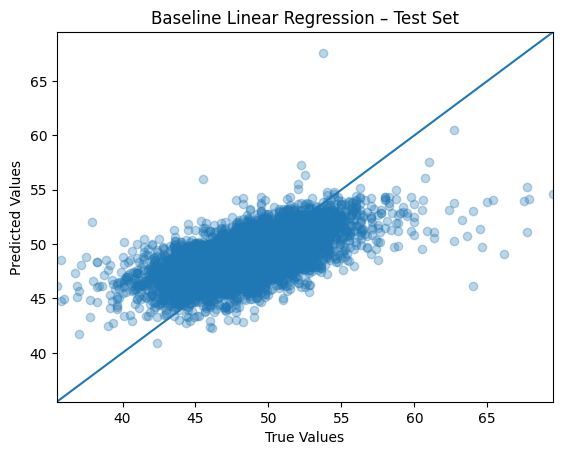

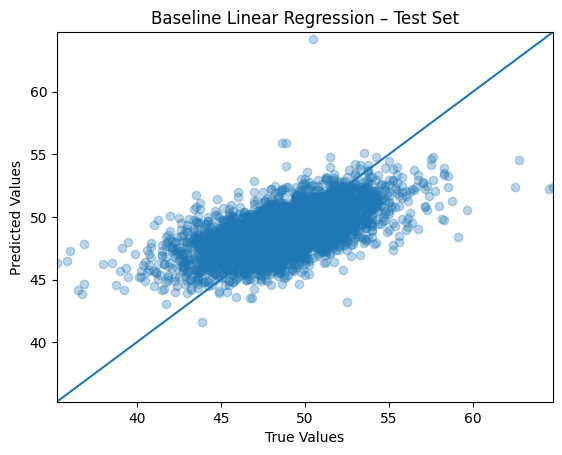

In [65]:
# Plot predictions
plot_predictions(linreg_pipeline, df_train[FEATURES], df_train[TARGET], title="Baseline Linear Regression – Test Set")
plot_predictions(linreg_pipeline, df_test[FEATURES], df_test[TARGET], title="Baseline Linear Regression – Test Set")

In [81]:
# Evaluate baseline model performance
metrics_train_linreg = get_regression_metrics(linreg_pipeline, df_train[FEATURES], df_train[TARGET])
metrics_test_linreg = get_regression_metrics(linreg_pipeline, df_test[FEATURES], df_test[TARGET])

print("Linear Regression - Train Metrics:", metrics_train_linreg)
print("Linear Regression - Test Metrics:", metrics_test_linreg)

Linear Regression - Train Metrics: {'mae': np.float64(1.6695138807820924), 'mse': np.float64(5.022528348109803), 'rmse': np.float64(2.241099807708216), 'r2': 0.36508940202019113, 'max_error': 17.83432740130732, 'mape': np.float64(0.03457391320261683)}
Linear Regression - Test Metrics: {'mae': np.float64(1.674455764503469), 'mse': np.float64(4.903121829966058), 'rmse': np.float64(2.2142993993509683), 'r2': 0.35871147080645116, 'max_error': 13.687091131324948, 'mape': np.float64(0.03468411209916981)}


# Linear Model -- Ridge Regression Model (Kelsy)

In [54]:
# Define model
ridge = Ridge(random_state=42)

In [20]:
# Set up pipeline
ridge_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),   # remove low variance feature
    ('scaling', StandardScaler()),                 # standardized
    ('ridge', ridge)
])

In [22]:
# Define parameter grid
param_grid_ridge = {
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]  # L2 Regularization Strength
}

# Randomized search for best parameters
ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_grid_ridge,
    n_iter=7,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [25]:
# Fit model
ridge_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('ridge',
                                              Ridge(random_state=42))]),
                   n_iter=7, n_jobs=-1,
                   param_distributions={'ridge__alpha': [0.0001, 0.001, 0.01,
                                                         0.1, 1, 10, 100]},
                   random_state=42, scoring='r2')

In [26]:
# Display best model
print("Best Ridge parameters:", ridge_search.best_params_)


Best Ridge parameters: {'ridge__alpha': 100}


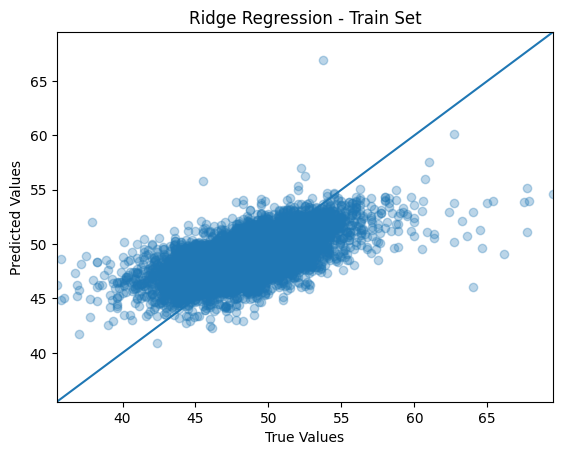

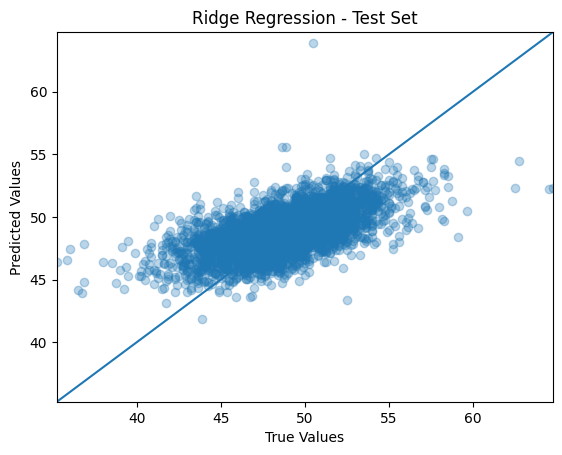

In [57]:
# Plot predictions
plot_predictions(ridge_search, df_train[FEATURES], df_train[TARGET], title="Ridge Regression - Train Set")
plot_predictions(ridge_search, df_test[FEATURES], df_test[TARGET], title="Ridge Regression - Test Set")

In [80]:
# Ridge Model Performance
metrics_train_ridge = get_regression_metrics(ridge_search, df_train[FEATURES], df_train[TARGET])
metrics_test_ridge = get_regression_metrics(ridge_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_ridge)
print("Test metrics:", metrics_test_ridge)

Train metrics: {'mae': np.float64(1.6687792837899023), 'mse': np.float64(5.023626441191644), 'rmse': np.float64(2.2413447840953977), 'r2': 0.3649505892775031, 'max_error': 17.90083458910963, 'mape': np.float64(0.03456161126213202)}
Test metrics: {'mae': np.float64(1.67333877733954), 'mse': np.float64(4.899402909203767), 'rmse': np.float64(2.2134594889457015), 'r2': 0.3591978754499706, 'max_error': 13.39387260323209, 'mape': np.float64(0.034664912460383716)}


# Linear Model -- Lasso Regression (Kelsy)

In [29]:
# Define Model
lasso = Lasso(max_iter=10000, random_state=42)

In [30]:
# Set up pipeline
lasso_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('lasso', lasso)
])

In [31]:
# Define Parameter Grid
param_grid_lasso = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=param_grid_lasso,
    n_iter=6,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [32]:
# Fit Model
lasso_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('lasso',
                                              Lasso(max_iter=10000,
                                                    random_state=42))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'lasso__alpha': [0.0001, 0.001, 0.01,
                                                         0.1, 1, 10]},
                   random_state=42, scoring='r2')

In [38]:
# Display best model
print("Best Lasso parameters:", lasso_search.best_params_)

Best Lasso parameters: {'lasso__alpha': 0.01}


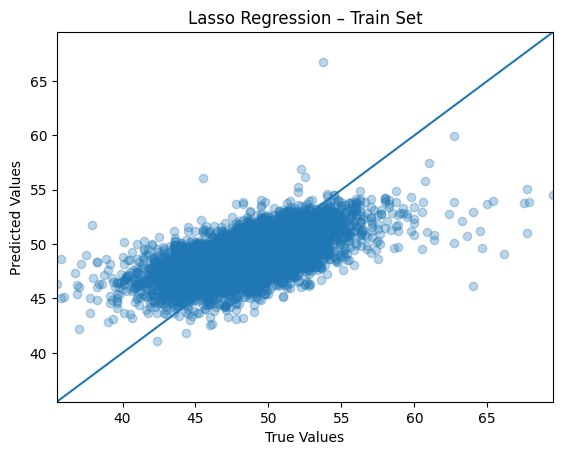

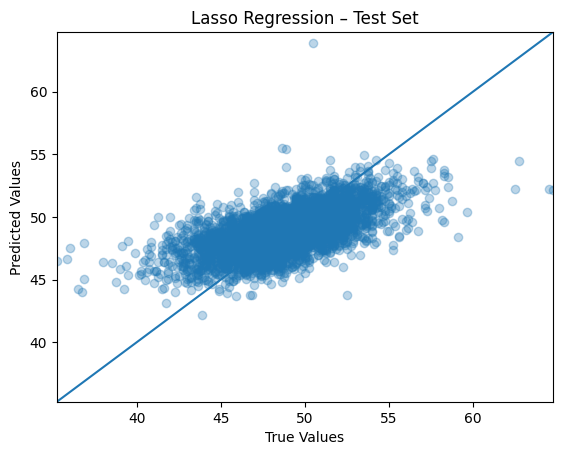

In [39]:
# Plot predictions
plot_predictions(lasso_search, df_train[FEATURES], df_train[TARGET], title="Lasso Regression – Train Set")
plot_predictions(lasso_search, df_test[FEATURES], df_test[TARGET], title="Lasso Regression – Test Set")

In [79]:
# Evaluate Lasso Performance
metrics_train_lasso = get_regression_metrics(lasso_search, df_train[FEATURES], df_train[TARGET])
metrics_test_lasso = get_regression_metrics(lasso_search, df_test[FEATURES], df_test[TARGET])
print("Train metrics:", metrics_train_lasso)
print("Test metrics:", metrics_test_lasso)

Train metrics: {'mae': np.float64(1.6699049516521294), 'mse': np.float64(5.0330985977242895), 'rmse': np.float64(2.2434568410656555), 'r2': 0.36375318985006866, 'max_error': 17.88381718365104, 'mape': np.float64(0.03458964854198057)}
Test metrics: {'mae': np.float64(1.67325128406106), 'mse': np.float64(4.899000735757854), 'rmse': np.float64(2.213368639824341), 'r2': 0.3592504764716369, 'max_error': 13.390433023314564, 'mape': np.float64(0.03466793117691436)}


# KNN Model (Kelsy)

In [47]:
# Define model
knn = KNeighborsRegressor()

In [48]:
# Set up pipeline
knn_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),  # remove near and constant features
    ('scaling', StandardScaler()),
    ('knn', knn)
])

In [49]:
# Define Parameter Grid
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'knn__weights': ['uniform', 'distance'],      #equal weight + closer neighbors weigh more
    'knn__p': [1, 2]
}

knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_grid_knn,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [50]:
# Train model
knn_search.fit(df_train[FEATURES], df_train[TARGET])

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('knn', KNeighborsRegressor())]),
                   n_jobs=-1,
                   param_distributions={'knn__n_neighbors': [3, 5, 7, 9, 11, 15,
                                                             20],
                                        'knn__p': [1, 2],
                                        'knn__weights': ['uniform',
                                                         'distance']},
                   random_state=42, scoring='r2')

In [51]:
# Display best model
print("Best KNN parameters:", knn_search.best_params_)

Best KNN parameters: {'knn__weights': 'distance', 'knn__p': 1, 'knn__n_neighbors': 7}


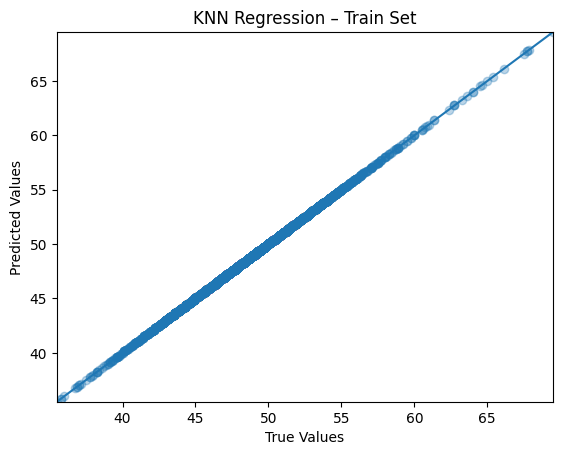

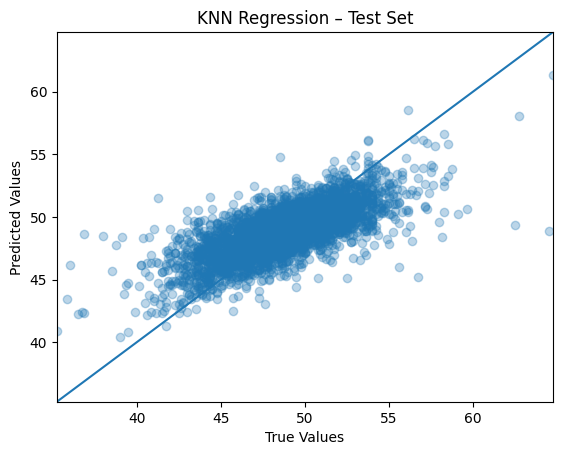

In [52]:
# Plot predictions

plot_predictions(knn_search, df_train[FEATURES], df_train[TARGET], title="KNN Regression – Train Set")
plot_predictions(knn_search, df_test[FEATURES], df_test[TARGET], title="KNN Regression – Test Set")

In [74]:
# Evaluate KNN Performance
metrics_train_knn = get_regression_metrics(knn_search, df_train[FEATURES], df_train[TARGET])
metrics_test_knn = get_regression_metrics(knn_search, df_test[FEATURES], df_test[TARGET])

print("Train metrics:", metrics_train_knn)
print("Test metrics:", metrics_test_knn)

Train metrics: {'mae': np.float64(0.0), 'mse': np.float64(0.0), 'rmse': np.float64(0.0), 'r2': 1.0, 'max_error': 0.0, 'mape': np.float64(0.0)}
Test metrics: {'mae': np.float64(1.4060012927934271), 'mse': np.float64(3.718547932798998), 'rmse': np.float64(1.9283536845711158), 'r2': 0.5136441195513005, 'max_error': 15.655567661819909, 'mape': np.float64(0.029074064087176943)}


# Kernel Ridge Regression (RBF) Model (Fiona)

In [10]:
# Define model
krr = KernelRidge(kernel='rbf')

In [11]:
# Set up pipeline
krr_pipeline = Pipeline([
    ('variance threshold', VarianceThreshold()),
    ('scaling', StandardScaler()),
    ('krr', krr)
])

In [12]:
# Define parameter grid
param_grid_krr = {
    'variance threshold__threshold': [0],
    'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
    'krr__gamma': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Randomized search for best parameters
random_param_grid_krr = RandomizedSearchCV(
    krr_pipeline,
    param_distributions=param_grid_krr,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [13]:
# Fit model
random_param_grid_krr.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('scaling', StandardScaler()),
                                             ('krr',
                                              KernelRidge(kernel='rbf'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'krr__alpha': [0.001, 0.01, 0.1, 1, 10],
                                        'krr__gamma': [1e-05, 0.0001, 0.001,
                                                       0.01, 0.1],
                                        'variance threshold__threshold': [0]},
                   verbose=2)

In [16]:
# Display best model
print(random_param_grid_krr.best_estimator_)

Pipeline(steps=[('variance threshold', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('krr', KernelRidge(alpha=0.001, gamma=0.0001, kernel='rbf'))])


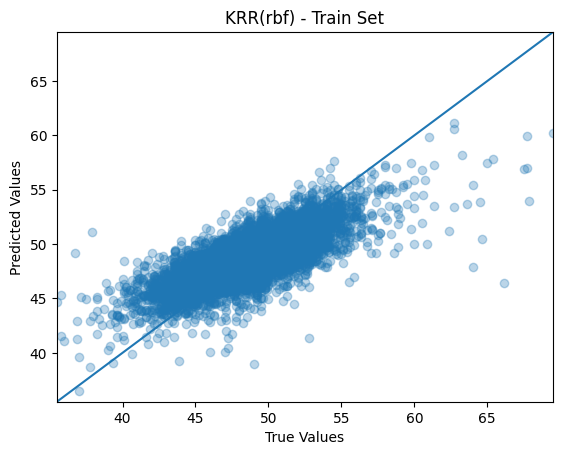

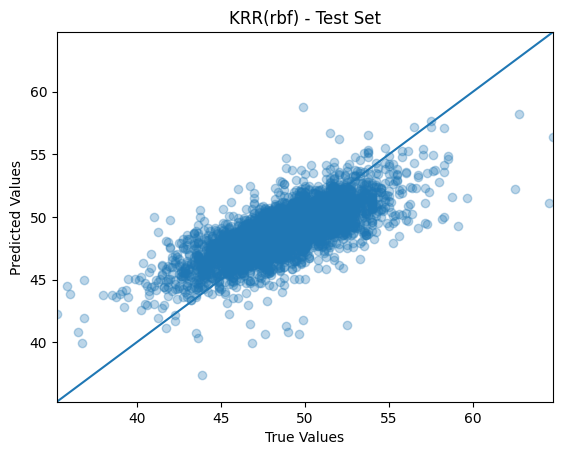

In [46]:
# Plot predictions
plot_predictions(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET], title='KRR(rbf) - Train Set')
plot_predictions(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET], title='KRR(rbf) - Test Set')

In [78]:
# Evaluate KRR-rbf performance
metrics_train = get_regression_metrics(random_param_grid_krr.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test = get_regression_metrics(random_param_grid_krr.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train)
print("Test metrics:", metrics_test)

Training metrics: {'mae': np.float64(1.3755568697166876), 'mse': np.float64(3.4717753371273634), 'rmse': np.float64(1.8632700655372971), 'r2': 0.5611240390157979, 'max_error': 19.7416790155512, 'mape': np.float64(0.028363731630329982)}
Test metrics: {'mae': np.float64(1.4128284399451765), 'mse': np.float64(3.5868615790184064), 'rmse': np.float64(1.8939011534444996), 'r2': 0.5308676255255343, 'max_error': 13.370183880040713, 'mape': np.float64(0.029130605235581992)}


# Random Forest Model

In [67]:
# Define model
feat_variance = df_train.var(axis='rows')

In [69]:
# Set up pipeline
rf = RandomForestRegressor(n_jobs=-1, warm_start=True)

In [70]:
rf_pipeline = Pipeline(
    [
        ('variance threshold', VarianceThreshold()),
        # ('scaling', StandardScaler()),
        ('rf', rf)
    ]
)

In [71]:
# Define parameter grid for RandomizedSearchCV
param_grid_rf = {
    'variance threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    # 'scaling': [None, MinMaxScaler(), StandardScaler()]
    'rf__n_estimators': [100, 1000],
    'rf__max_depth': [10, 20, 50],
    'rf__min_samples_leaf': [4, 8, 16, 32]
}

# Randomized search for best model
random_param_grid_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_grid_rf, n_iter=20,
                        cv=5, verbose=2, n_jobs=-1)

In [72]:
# Fit model
random_param_grid_rf.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('rf',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    warm_start=True))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'rf__max_depth': [10, 20, 50],
                                        'rf__min_samples_leaf': [4, 8, 16, 32],
                                        'rf__n_estimators': [100, 1000],
                                        'variance threshold__threshold': [0,
                                                                          np.float64(0.0),
                                                                          np.float64(0.0),
                                                                          np.float64(0.2590114113136173),
                                                                          np.float64(816.5059159956219),
                                                                          np.float64(19436.614157004362),
                                                                          np.float64(742858.793412197)]},
                   verbose=2)

In [75]:
# Display the best model
print(random_param_grid_rf.best_estimator_)

Pipeline(steps=[('variance threshold',
                 VarianceThreshold(threshold=np.float64(0.0))),
                ('rf',
                 RandomForestRegressor(max_depth=50, min_samples_leaf=8,
                                       n_estimators=1000, n_jobs=-1,
                                       warm_start=True))])


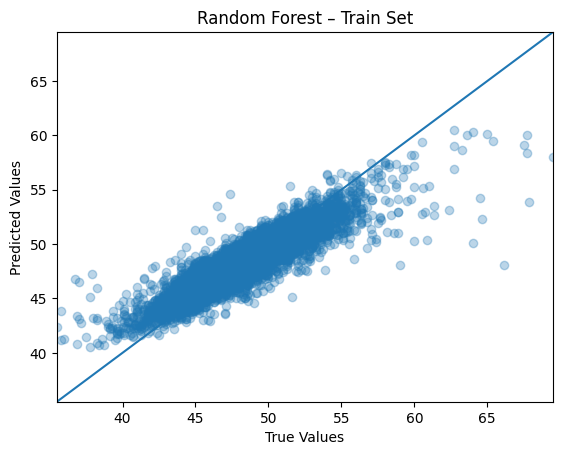

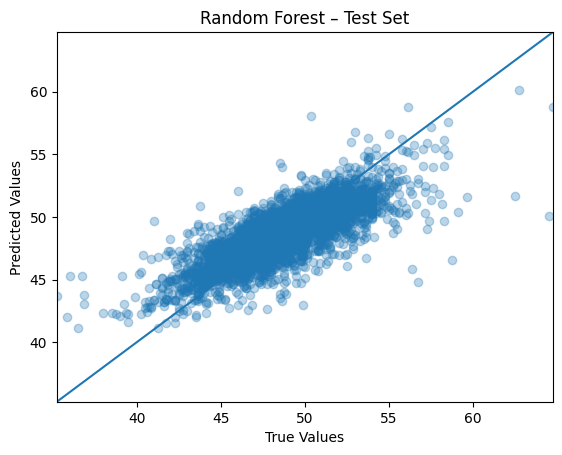

In [76]:
# Plot predictions
plot_predictions(random_param_grid_rf.best_estimator_, df_train[FEATURES], df_train[TARGET], title="Random Forest – Train Set")
plot_predictions(random_param_grid_rf.best_estimator_, df_test[FEATURES], df_test[TARGET], title="Random Forest – Test Set")

In [77]:
# Evaluate Random Forest performance
metrics_train_rf = get_regression_metrics(random_param_grid_rf.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test_rf = get_regression_metrics(random_param_grid_rf.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train_rf)
print("Test metrics:", metrics_test_rf)

Training metrics: {'mae': np.float64(0.9060200015432099), 'mse': np.float64(1.6720468737086953), 'rmse': np.float64(1.2930765150248051), 'r2': 0.7886322969513583, 'max_error': 18.055173842010845, 'mape': np.float64(0.018605124532949324)}
Test metrics: {'mae': np.float64(1.261283072621866), 'mse': np.float64(2.9643927987069616), 'rmse': np.float64(1.7217412113052768), 'r2': 0.6122814884557142, 'max_error': 14.431650166957361, 'mape': np.float64(0.025919973096290974)}


# Gradient Boosting Model

In [82]:
# Define model
gb = GradientBoostingRegressor(warm_start=True)

In [83]:
# Set up pipeline
gb_pipeline = Pipeline(
    [
        ('variance threshold', VarianceThreshold()),
        # ('scaling', StandardScaler()),
        ('gb', gb)
    ]
)

In [84]:
# Define parameter grid for RandomizedSearchCV
param_grid_gb = {
    'variance threshold__threshold': [0, feat_variance.quantile(0.05), feat_variance.quantile(0.1), feat_variance.quantile(0.2), feat_variance.quantile(0.4), feat_variance.quantile(0.6), feat_variance.quantile(0.8)],
    'gb__n_estimators': [100, 200, 500],
    'gb__learning_rate': [0.01, 0.1, 0.2, 0.5],
    'gb__max_depth': [3, 4, 5, 6],
    'gb__min_samples_leaf': [1, 3, 5, 10],
    'gb__max_features': ['sqrt', 'log2', None],
    'gb__loss': ['squared_error', 'absolute_error'],
}

# Randomized search for best model
random_param_grid_gb = RandomizedSearchCV(gb_pipeline, param_distributions=param_grid_gb, n_iter=20,
                        cv=5, verbose=2, n_jobs=-1)

In [85]:
# Fit model
random_param_grid_gb.fit(df_train[FEATURES], df_train[TARGET])

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('variance threshold',
                                              VarianceThreshold()),
                                             ('gb',
                                              GradientBoostingRegressor(warm_start=True))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'gb__learning_rate': [0.01, 0.1, 0.2,
                                                              0.5],
                                        'gb__loss': ['squared_error',
                                                     'absolute_error'],
                                        'gb__max_depth': [3, 4, 5, 6],
                                        'gb__max_features': ['sqrt', 'log2',
                                                             None],
                                        'gb__min_samples_leaf': [1, 3, 5, 10],
                                        'gb__n_estimators': [100, 200, 500],
                                        'variance threshold__threshold': [0,
                                                                          np.float64(0.0),
                                                                          np.float64(0.0),
                                                                          np.float64(0.2590114113136173),
                                                                          np.float64(816.5059159956219),
                                                                          np.float64(19436.614157004362),
                                                                          np.float64(742858.793412197)]},
                   verbose=2)

In [86]:
# Display the best model
print(random_param_grid_gb.best_estimator_)

Pipeline(steps=[('variance threshold',
                 VarianceThreshold(threshold=np.float64(0.0))),
                ('gb',
                 GradientBoostingRegressor(max_depth=6, max_features='sqrt',
                                           n_estimators=200,
                                           warm_start=True))])


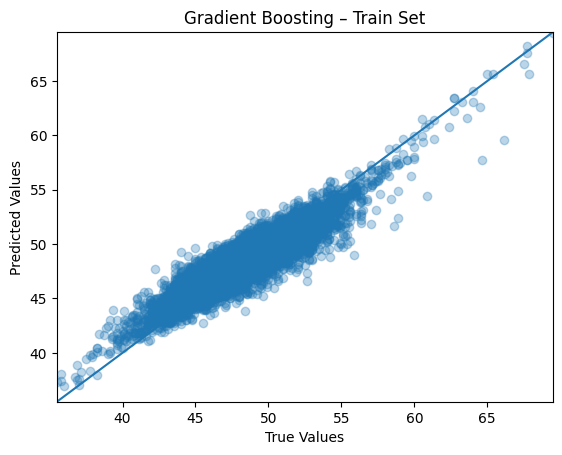

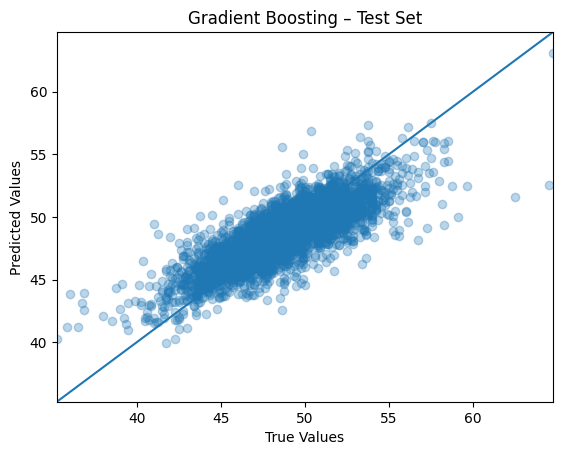

In [87]:
# Plot predictions
plot_predictions(random_param_grid_gb.best_estimator_, df_train[FEATURES], df_train[TARGET], title="Gradient Boosting – Train Set")
plot_predictions(random_param_grid_gb.best_estimator_, df_test[FEATURES], df_test[TARGET], title="Gradient Boosting – Test Set")

In [88]:
# Evaluate Random Forest performance
metrics_train_gb = get_regression_metrics(random_param_grid_gb.best_estimator_, df_train[FEATURES], df_train[TARGET])
metrics_test_gb = get_regression_metrics(random_param_grid_gb.best_estimator_, df_test[FEATURES], df_test[TARGET])

print("Training metrics:", metrics_train_gb)
print("Test metrics:", metrics_test_gb)

Training metrics: {'mae': np.float64(0.9263305015889649), 'mse': np.float64(1.4432734167983867), 'rmse': np.float64(1.2013631494258457), 'r2': 0.8175521321939998, 'max_error': 6.94316460954208, 'mape': np.float64(0.019043692409677026)}
Test metrics: {'mae': np.float64(1.2280679331137019), 'mse': np.float64(2.7277809485379065), 'rmse': np.float64(1.6515995121511469), 'r2': 0.6432283975162478, 'max_error': 11.92050734614309, 'mape': np.float64(0.025207845504220297)}
